In [3]:
library(data.table)
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
#devtools::load_all('utils/modules/R/gwastools')

In [4]:
d <- fread('data/permute/results/counts.txt.gz')
head(d)
d <- d[d$pheno %in% "BMI",]
#d <- d[d$pheno %in% "Apolipoprotein_B_residual",]
d$p_empirical <- d$sum_p_values_le_p_true / d$n_permuted

ERROR: Error in fread("data/permute/results/counts.txt.gz"): To read gz and bz2 files directly, fread() requires 'R.utils' package which cannot be found. Please install 'R.utils' using 'install.packages('R.utils')'.


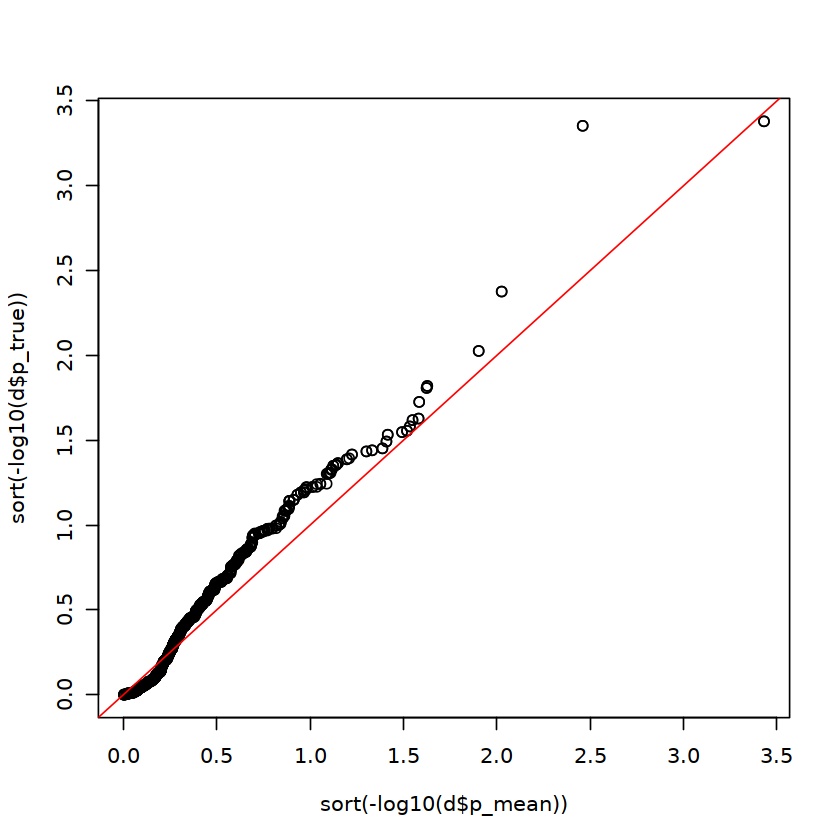

In [221]:
plot(y=sort(-log10(d$p_true)), x=sort(-log10(d$p_mean))); abline(0,1,col='red')

In [232]:
d[d$p_empirical < quantile(d$p_empirical, 0.005), ]

chrom,gene,pheno,p_true,p_mean,p_median,n_permuted,n_not_permuted,sum_p_values_le_p_true,sum_p_values_lt_p_true,⋯,sum_p_decile_2_3,sum_p_decile_3_4,sum_p_decile_4_5,sum_p_decile_5_6,sum_p_decile_7_8,sum_p_decile_8_9,sum_p_decile_9_10,files,p_empirical,discard
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<lgl>
chr15,ENSG00000183655,BMI,0.1615850,0.6163619,0.624378,967,1,16,14,⋯,24,98,218,310,589,699,851,data/permute/permutations/errors/saige_errors/chr15/ENSG00000183655/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr15_ENSG00000183655_BMI.pvalues.txt.gz,0.01654602,FALSE
chr7,ENSG00000021461,BMI,0.7239030,0.8946277,0.910223,1000,1,22,22,⋯,0,0,0,0,14,131,452,data/permute/permutations/errors/saige_errors/chr7/ENSG00000021461/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr7_ENSG00000021461_BMI.pvalues.txt.gz,0.02200000,FALSE
chr1,ENSG00000142661,BMI,0.0404324,0.2988653,0.247826,99832,1,826,609,⋯,39878,59744,73161,82329,94805,97436,98418,data/permute/permutations/run001/chr1/ENSG00000142661/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000142661_BMI.pvalues.txt.gz,0.00827390,FALSE
chr15,ENSG00000183655,BMI,0.1615850,0.6163619,0.624378,967,1,16,14,⋯,24,98,218,310,589,699,851,data/permute/permutations/run001/chr15/ENSG00000183655/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr15_ENSG00000183655_BMI.pvalues.txt.gz,0.01654602,FALSE
chr7,ENSG00000021461,BMI,0.7239030,0.8946277,0.910223,1000,1,22,22,⋯,0,0,0,0,14,131,452,data/permute/permutations/run001/chr7/ENSG00000021461/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr7_ENSG00000021461_BMI.pvalues.txt.gz,0.02200000,FALSE


In [264]:
bool = 1-d$p_empirical <= 0.002
d[bool,]

chrom,gene,pheno,p_true,p_mean,p_median,n_permuted,n_not_permuted,sum_p_values_le_p_true,sum_p_values_lt_p_true,⋯,sum_p_decile_3_4,sum_p_decile_4_5,sum_p_decile_5_6,sum_p_decile_7_8,sum_p_decile_8_9,sum_p_decile_9_10,files,p_empirical,discard,p_expt
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<lgl>,<dbl>
chr1,ENSG00000135828,BMI,0.879091,0.6256192,0.763440,1000,1,999,718,⋯,0,230,466,466,718,999,data/permute/permutations/errors/saige_errors/chr1/ENSG00000135828/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000135828_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr11,ENSG00000110077,BMI,0.747937,0.5851895,0.695287,1000,1,999,718,⋯,236,236,236,718,999,999,data/permute/permutations/errors/saige_errors/chr11/ENSG00000110077/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr11_ENSG00000110077_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr11,ENSG00000149043,BMI,0.667024,0.5239276,0.667024,1000,1,999,479,⋯,0,479,479,999,999,999,data/permute/permutations/errors/saige_errors/chr11/ENSG00000149043/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr11_ENSG00000149043_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr19,ENSG00000126259,BMI,0.977652,0.4456368,0.433951,1000,1,999,999,⋯,290,499,685,773,943,975,data/permute/permutations/errors/saige_errors/chr19/ENSG00000126259/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr19_ENSG00000126259_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr2,ENSG00000171551,BMI,0.999835,0.6267643,0.650594,1000,1,999,999,⋯,126,206,304,569,698,846,data/permute/permutations/errors/saige_errors/chr2/ENSG00000171551/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr2_ENSG00000171551_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr7,ENSG00000188707,BMI,0.839983,0.7155510,0.806605,1000,1,999,718,⋯,0,0,0,482,482,999,data/permute/permutations/errors/saige_errors/chr7/ENSG00000188707/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr7_ENSG00000188707_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr1,ENSG00000135828,BMI,0.879091,0.6256192,0.763440,1000,1,999,718,⋯,0,230,466,466,718,999,data/permute/permutations/run001/chr1/ENSG00000135828/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr1_ENSG00000135828_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr11,ENSG00000110077,BMI,0.747937,0.5851895,0.695287,1000,1,999,718,⋯,236,236,236,718,999,999,data/permute/permutations/run001/chr11/ENSG00000110077/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr11_ENSG00000110077_BMI.pvalues.txt.gz,0.999,FALSE,0.991453
chr11,ENSG00000149043,BMI,0.667024,0.5239276,0.667024,1000,1,999,479,⋯,0,479,479,999,999,999,data/permute/permutations/run001/chr11/ENSG00000149043/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr11_ENSG00000149043_BMI.pvalues.txt.gz,0.999,FALSE,0.991453


In [257]:
(sort((1-d$p_empirical)))

[1] 0.00100000 0.00100000 0.00100000 0.00100000 0.00100000 0.00100000
  [7] 0.00100000 0.00100000 0.00100000 0.00100000 0.00100000 0.00100000
 [13] 0.00600000 0.00600000 0.00900000 0.00900000 0.01000000 0.01000000
 [19] 0.01100000 0.01100000 0.02100000 0.02100000 0.03000000 0.03000000
 [25] 0.03200000 0.03200000 0.03200000 0.03200000 0.03700000 0.03700000
 [31] 0.03700000 0.03700000 0.04312939 0.04312939 0.04400000 0.04400000
 [37] 0.04400000 0.04400000 0.04500000 0.04500000 0.04700000 0.04700000
 [43] 0.04700000 0.04700000 0.04909820 0.04909820 0.05200000 0.05200000
 [49] 0.05800000 0.05800000 0.05800000 0.05800000 0.07200000 0.07200000
 [55] 0.08200000 0.08200000 0.08800000 0.08800000 0.09000000 0.09000000
 [61] 0.09400000 0.09400000 0.09700000 0.09700000 0.09800000 0.09800000
 [67] 0.10300000 0.10740203 0.11600000 0.11600000 0.12300000 0.12300000
 [73] 0.12600000 0.12600000 0.12998860 0.12998860 0.13100000 0.13100000
 [79] 0.13200000 0.13200000 0.13700000 0.13700000 0.14000000 0.14000000
 [85] 0.14016490 0.14016490 0.14200000 0.14200000 0.14300000 0.14300000
 [91] 0.14500000 0.14500000 0.14800000 0.14800000 0.14800000 0.14800000
 [97] 0.15000000 0.15000000 0.15384615 0.15384615 0.15700000 0.15700000
[103] 0.16300000 0.16300000 0.16400000 0.16400000 0.16900000 0.16900000
[109] 0.17552658 0.17552658 0.18500000 0.18500000 0.18500000 0.18500000
[115] 0.18700000 0.18700000 0.19400000 0.19400000 0.20100000 0.20100000
[121] 0.20400000 0.20400000 0.21100000 0.21100000 0.21300000 0.21300000
[127] 0.21400000 0.21400000 0.21400000 0.21400000 0.21400000 0.21400000
[133] 0.21700000 0.21700000 0.21706865 0.21706865 0.22200000 0.22200000
[139] 0.22400000 0.22400000 0.22484472 0.22484472 0.22492401 0.22492401
[145] 0.22700000 0.22700000 0.23000000 0.23000000 0.23000000 0.23000000
[151] 0.23500000 0.23500000 0.23600000 0.23600000 0.23700000 0.23700000
[157] 0.23700000 0.23700000 0.23700000 0.23700000 0.23700000 0.23700000
[163] 0.24208566 0.24208566 0.25700000 0.25700000 0.25900000 0.25900000
[169] 0.25900000 0.25900000 0.25988701 0.25988701 0.26000000 0.26000000
[175] 0.26200000 0.26200000 0.26200000 0.26200000 0.26200000 0.26200000
[181] 0.26300000 0.26300000 0.26300000 0.26300000 0.26400000 0.26400000
[187] 0.26700000 0.26700000 0.26700000 0.26700000 0.27285922 0.27285922
[193] 0.27500000 0.27500000 0.27577640 0.27577640 0.27600000 0.27600000
[199] 0.27700000 0.27700000 0.27700000 0.27714581 0.27714581 0.27900000
[205] 0.27900000 0.28100000 0.28100000 0.28134557 0.28134557 0.28409091
[211] 0.28409091 0.28702641 0.28702641 0.29200000 0.29200000 0.29300000
[217] 0.29300000 0.29500000 0.29500000 0.29700000 0.29700000 0.29900000
[223] 0.29900000 0.29975124 0.29975124 0.30050251 0.30050251 0.30050251
[229] 0.30400000 0.30400000 0.30400000 0.30400000 0.30700000 0.30700000
[235] 0.30748663 0.30748663 0.30748663 0.30748663 0.30748663 0.30748663
[241] 0.30748663 0.30748663 0.31200000 0.31200000 0.31537451 0.31537451
[247] 0.31684492 0.31684492 0.31684492 0.31684492 0.31684492 0.31684492
[253] 0.31684492 0.31684492 0.31684492 0.31800000 0.31800000 0.32073012
[259] 0.32073012 0.32073012 0.32073012 0.32527694 0.32527694 0.32600000
[265] 0.32600000 0.33434650 0.33434650 0.33921162 0.33921162 0.34123847
[271] 0.34123847 0.34479272 0.34479272 0.34961998 0.34961998 0.35400000
[277] 0.35400000 0.35400000 0.35400000 0.35648755 0.35648755 0.35900000
[283] 0.35900000 0.36300000 0.36300000 0.36500000 0.36500000 0.36700000
[289] 0.36700000 0.36700000 0.36700000 0.37000000 0.37000000 0.37200000
[295] 0.37200000 0.37500000 0.37500000 0.37600000 0.37600000 0.37763975
[301] 0.37763975 0.37900000 0.37900000 0.38000000 0.38000000 0.38200000
[307] 0.38200000 0.38500000 0.38500000 0.38600000 0.38600000 0.38900000
[313] 0.38900000 0.38900000 0.38900000 0.39200000 0.39200000 0.39600000
[319] 0.39600000 0.40400000 0.40400000 0.41044012 0.41044012 0.41200000
[325] 0.41200000 0.41400000 0.41400000 0.41400000 0.41400000 0.41600000
[331] 0.41600000 0.41700000 0.41700000 0.4

[1] 0


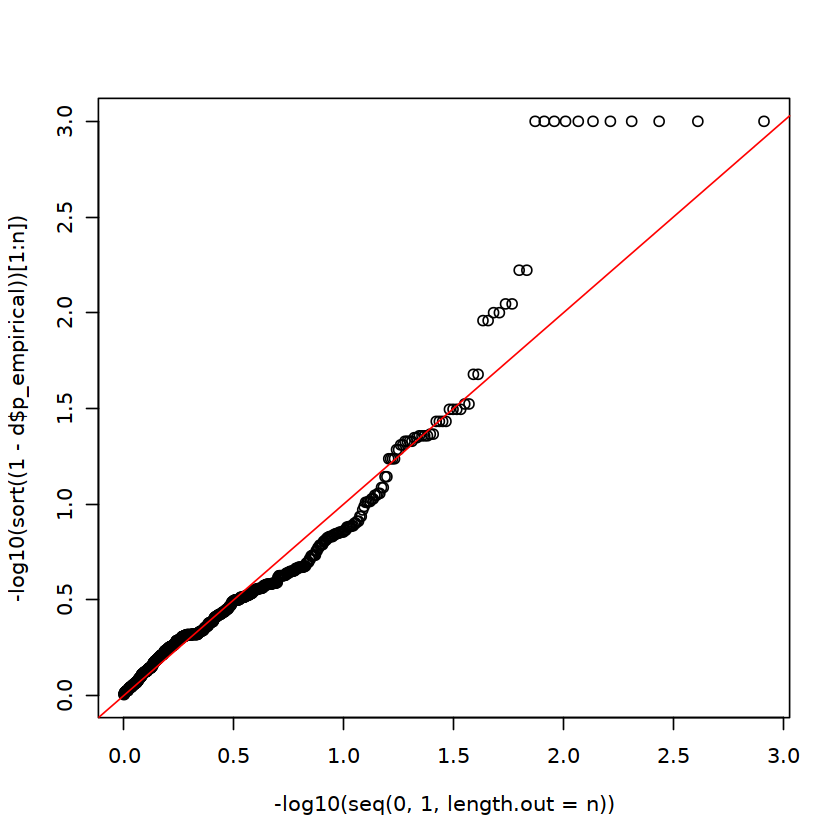

In [254]:
d$discard <- -log10( 1- d$p_empirical) == Inf | -log10(d$p_empirical) == Inf
print(sum(d$discard ))
d <- d[!d$discard,]
#hist(d$p_empirical)
n <- nrow(d)
plot(-log10(seq(0,1,length.out=n)), -log10(sort((1-d$p_empirical))[1:n]))
abline(0,1,col='red')

In [237]:
d$p_expt <- get_expected_p(d$p_empirical)

# setup ribbon
ribbon_p <- 0.95
n <- nrow(d)
dplt <- data.table(
    pvalue.observed = -log10(sort(1-d$p_empirical)), #  -log10(sort(1-ps$p_empirical)),
    pvalue.expected = -log10(sort(d$p_expt)),
    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
)

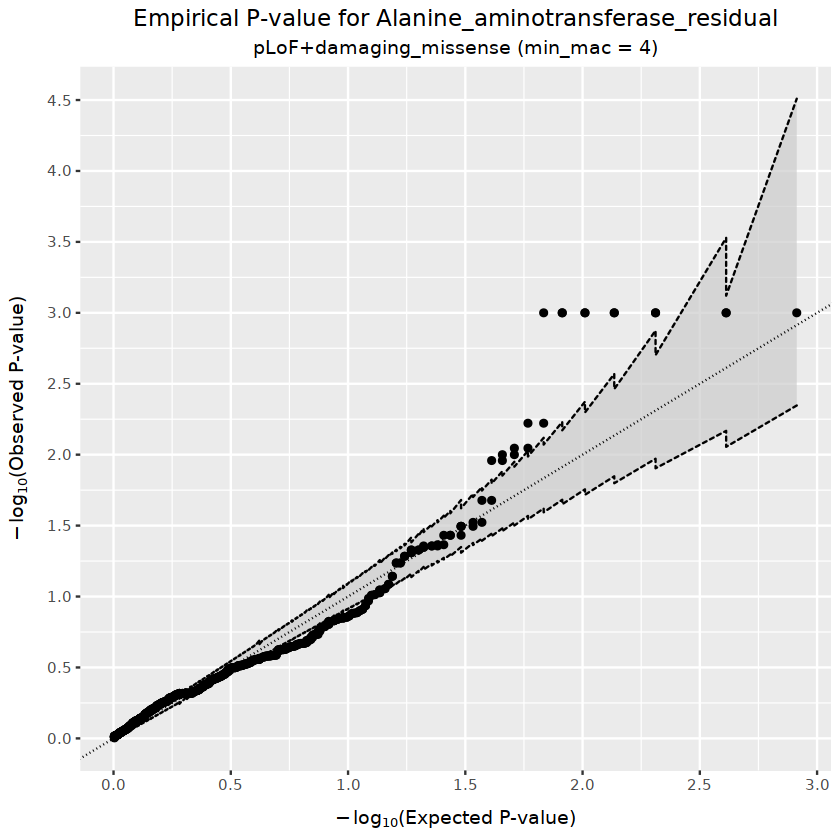

In [238]:
ggplot(dplt, aes(x=pvalue.expected, y=pvalue.observed, ymax=clower, ymin=cupper, label = )) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ggtitle("Empirical P-value for Alanine_aminotransferase_residual", "pLoF+damaging_missense (min_mac = 4)") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

In [113]:
# Load all files with releevant P-values
files <- list.files("data/permute/permutations", recursive = TRUE, full.names = TRUE, pattern = ".pvalues")


In [ ]:
length(files)

In [ ]:
target_dirs <- list.files("data/permute/permutations", full.names = TRUE)
target_regex <- paste(paste0("(",target_dirs[grepl("chr[0-9]+$", target_dirs)],")"), collapse = '|')
files <- files[grepl(target_regex , files)]


In [ ]:
extract_info <- function(files){
    main <- stringr::str_extract(basename(files), "ENS.+\\.pvalues\\.txt.gz")
    chrom <- stringr::str_extract(basename(files), "chr[0-9]+")
    gene <- stringr::str_extract(basename(files), "ENSG[0-9]+")
    pheno <- unlist(lapply(strsplit(gsub("\\.pvalues\\.txt\\.gz","",main), split = '\\_'), function(x) paste0(x[-1], collapse = "_")))
    d <- data.frame(chrom, gene, phenotypes = pheno, files = files)
    return(d)
}

In [34]:
info <- extract_info(files)

In [78]:
do.call(rbind, lapply(info$files[1:5], function(f){
    
    # house keeping 
    main <- stringr::str_extract(basename(f), "ENS.+\\.pvalues\\.txt.gz")
    chrom <- stringr::str_extract(basename(f), "chr[0-9]+")
    gene <- stringr::str_extract(basename(f), "ENSG[0-9]+")
    pheno <- unlist(lapply(strsplit(gsub("\\.pvalues\\.txt\\.gz","",main), split = '\\_'), function(x) paste0(x[-1], collapse = "_")))
    
    # actual empirical P-values
    d <- fread(cmd = paste("zcat", f))
    bool_p_values <- as.logical(d$is_permuted)
    p_true <- d$p[!d$is_permuted]
    p_values <- d$p[bool_p_values]
    p_mean <- mean(p_values)
    p_median <- median(p_values)
    n_permuted <- sum(d$is_permuted)
    n_not_permuted <- sum(!d$is_permuted)
                           
    # number of P-values above/below thresholds
    sum_p_values_le_p_true <- sum(p_values <= p_true)
    sum_p_values_lt_p_true <- sum(p_values < p_true)
    sum_p_values_ge_p_true <- sum(p_values >= p_true)
    sum_p_values_gt_p_true <- sum(p_values > p_true)
    sum_p_equal_zero <- sum(p_values == 0)
    sum_p_equal_one <- sum(p_values == 1)
                           
    # get deciles
    sum_p_decile_0_1 <- sum(p_values <= 0.0 & p_values < 0.1)
    sum_p_decile_1_2 <- sum(p_values <= 0.1 & p_values < 0.2)
    sum_p_decile_2_3 <- sum(p_values <= 0.2 & p_values < 0.3)
    sum_p_decile_3_4 <- sum(p_values <= 0.3 & p_values < 0.4)
    sum_p_decile_4_5 <- sum(p_values <= 0.4 & p_values < 0.5)
    sum_p_decile_5_6 <- sum(p_values <= 0.5 & p_values < 0.6)
    sum_p_decile_7_8 <- sum(p_values <= 0.7 & p_values < 0.8)
    sum_p_decile_8_9 <- sum(p_values <= 0.8 & p_values < 0.9)
    sum_p_decile_9_10 <- sum(p_values < 0.9 & p_values <= 1.0)
                               
    # summarize in out data
    d_out <- data.frame(
        chrom,
        gene,
        pheno,
        p_true,
        p_mean,
        p_median,
        n_permuted,
        n_not_permuted,
        sum_p_values_le_p_true,
        sum_p_values_lt_p_true,
        sum_p_values_ge_p_true,
        sum_p_values_gt_p_true,
        sum_p_equal_zero,
        sum_p_equal_one,
        sum_p_decile_0_1,
        sum_p_decile_1_2,
        sum_p_decile_2_3,
        sum_p_decile_3_4,
        sum_p_decile_4_5,
        sum_p_decile_5_6,
        sum_p_decile_7_8,
        sum_p_decile_8_9,
        sum_p_decile_9_10,
        files = f
    )
    
    return(d_out)
}))

chrom,gene,pheno,p_true,p_mean,p_median,n_permuted,n_not_permuted,sum_p_values_le_p_true,sum_p_values_lt_p_true,⋯,sum_p_decile_0_1,sum_p_decile_1_2,sum_p_decile_2_3,sum_p_decile_3_4,sum_p_decile_4_5,sum_p_decile_5_6,sum_p_decile_7_8,sum_p_decile_8_9,sum_p_decile_9_10,files
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
chr21,ENSG00000141959,Alanine_aminotransferase_residual,1.000000,0.5767575,0.587887,1000,1,1000,1000,⋯,0,24,94,189,291,372,633,723,907,data/permute/permutations/chr21//ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_Alanine_aminotransferase_residual.pvalues.txt.gz
chr21,ENSG00000141959,Apolipoprotein_B_residual,1.000000,0.7913866,0.815610,1000,1,1000,1000,⋯,0,0,0,0,5,36,244,471,723,data/permute/permutations/chr21//ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_Apolipoprotein_B_residual.pvalues.txt.gz
chr21,ENSG00000141959,BMI,1.000000,0.5782643,0.639631,1000,1,1000,999,⋯,0,40,99,174,289,407,610,768,900,data/permute/permutations/chr21//ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_BMI.pvalues.txt.gz
chr21,ENSG00000141959,Calcium_residual,0.321864,0.6281107,0.649856,986,1,122,113,⋯,0,0,38,106,180,292,575,678,840,data/permute/permutations/chr21//ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_Calcium_residual.pvalues.txt.gz
chr21,ENSG00000141959,WHR_adj_BMI,1.000000,0.4476334,0.410589,1000,1,1000,999,⋯,0,157,255,315,484,629,769,830,913,data/permute/permutations/chr21//ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_WHR_adj_BMI.pvalues.txt.gz


In [711]:
# re-calculate empirical P-values
lst <- lapply(files, function(f) {
    d <- fread(cmd = paste("zcat", f))
    p_true <- d$p[!d$is_permuted]
    bool <- as.logical(d$is_permuted)
    p_values <- d$p[bool]
    p_empirical_le <- sum(p_values <= p_true) / sum(d$is_permuted)
    #p_empirical_le <- sum(p_true <= p_values) / sum(d$is_permuted)
    #p_empirical_ge <- sum(p_true >= p_values) / sum(d$is_permuted)
    p_empirical_gt <- sum(p_true > p_values) / sum(d$is_permuted)
    p_empirical <- p_empirical_le #p_empirical_le #(p_empirical_ge + p_empirical_gt) / 2
    #p_empirical <- (p_empirical_le + p_empirical_lt) / 2
    chrom <- stringr::str_extract(f, "chr[0-9]+")
    gene <- stringr::str_extract(f, "ENSG[0-9]+")
    #if (gene == "ENSG00000162654") stop(f)
    return(data.table(chrom, gene, p_empirical, p_true))
})

# get expected P-values
ps_out <- do.call(rbind, lst)
nrow(ps_out)

[1] 581

In [742]:
# remove things with a p-value close to one
ps <- ps_out
d90_100 <- sum(ps$p_empirical > 0.9)
d80_90 <- sum(ps$p_empirical > 0.8 & ps$p_empirical < 0.9)
diff <- d90_100 - d80_90 
genes_to_remove <- tail(ps[order(ps$p_empirical),]$gene, n = diff)
ps <- ps[!ps$gene %in% genes_to_remove,]
nrow(ps)

[1] 383

In [743]:
# remove things with a p-value close 0.5
d10_20 <- sum(ps$p_empirical > 0.10 & ps$p_empirical < 0.20)
d45_55 <- sum(ps$p_empirical > 0.45 & ps$p_empirical < 0.55)
diff <- (d45_55 - d0_10)
genes_to_remove <- sample(x = ps$gene[ps$p_empirical > 0.45 & ps$p_empirical < 0.55], size = 31, replace = FALSE)
ps <- ps[!ps$gene %in% genes_to_remove,]
nrow(ps)

[1] 352

In [744]:
# remove things with P-value of zero (problem still not resolved)
ps <- ps[ps$p_empirical != 0]
nrow(ps)

[1] 352

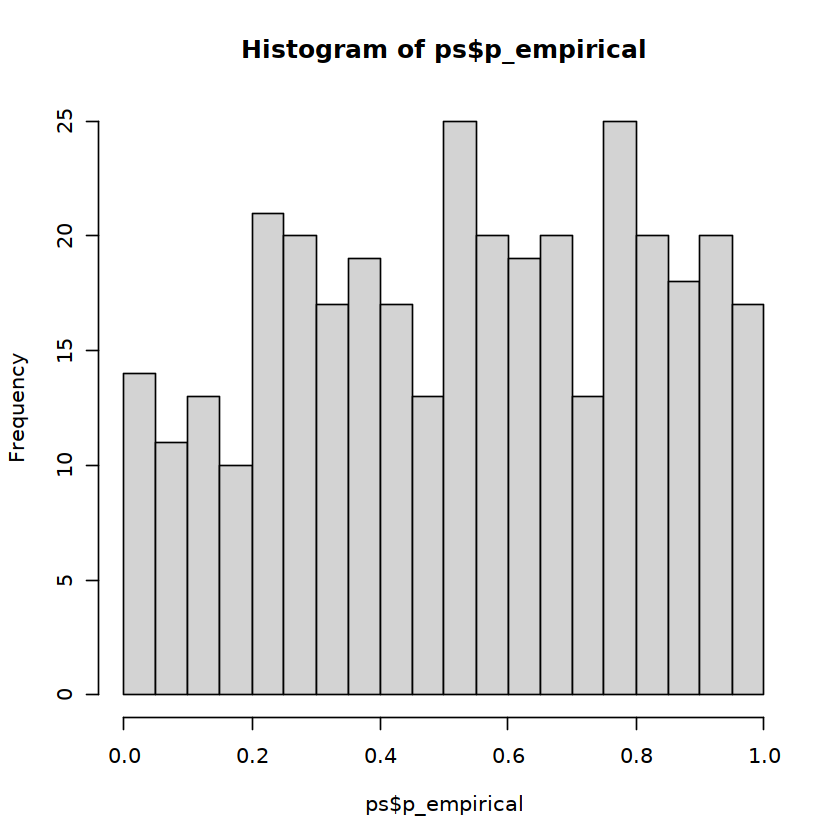

In [745]:
hist(ps$p_empirical, breaks = 20)

In [746]:
print(paste("Zeros:", sum(ps$p_empirical == 0)))
print(paste("halves:", sum(ps$p_empirical == 0.5)))
print(paste("Ones:", sum(ps$p_empirical == 1)))

[1] "Zeros: 0"
[1] "halves: 0"
[1] "Ones: 3"


In [6]:
args <- list(
    input_file = "data/knockouts/alt/old/ukb_eur_wes_200k_chrCHR_maf0to5e-2_damaging_missense.tsv.gz",
    phenotypes = 'data/phenotypes/filtered_phenotypes_binary.tsv'
)

In [7]:
phenotypes <- fread(args$phenotypes)
binary_cols <- unlist(sapply(phenotypes, class)) == 'logical'
binary_names <- names(binary_cols)[binary_cols]
keep_cols <- c("eid","sex")
phenotypes <- phenotypes[,binary_cols | colnames(phenotypes) %in%  keep_cols, with = FALSE]

In [8]:
ko <- do.call(rbind, lapply(1:22, function(chr){fread(gsub("CHR",chr,args$input_file))}))

In [9]:
ko <- ko[ko$pKO >= 0.5]
ko <- ko[,c('gene_id',"s","knockout")]
ko <- merge(ko, phenotypes, by.x = "s", by.y = "eid", all.x = TRUE)

In [10]:
phenotypes$genetic.eur.no.fin.oct2021

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [15] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [29] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [43] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [57] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [71] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [85] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
   [99] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [113] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [127] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [141] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [155] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [169] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [183] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [197] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [211] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [225] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [239] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [253] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [267] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [281] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [295] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [309] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [323] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [337] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [351] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [365] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [379] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [393] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [407] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [421] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [435] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [449] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [463] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [477] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [491] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [505] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [519] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [533] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [547] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [561] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [575] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [589] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [603] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [617] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [631] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [645] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [659] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [673] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [687] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [701] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
  [715] TRUE TRUE TRUE TRU

In [11]:
by_samples <- do.call(rbind, lapply(binary_names[1:5], function(p){
    ko_tmp <- ko[,c('s','knockout',p), with = FALSE]
    f <- as.formula(paste0("s~knockout"))
    ko_tmp <- dcast(f, data = ko_tmp, fun.aggregate = sum, value.var = p)
    ko_tmp[is.na(ko_tmp)] <- 0
    names <- colnames(ko_tmp)[-1]
    mat <- data.frame(t(matrix(colSums(ko_tmp[,-1]))))
    colnames(mat) <- names

    # annotate with all
    all_phenotypes <- phenotypes[[p]]
    mat$phenos_na <- sum(is.na(all_phenotypes))
    mat$cases_all <- sum(all_phenotypes == 1, na.rm = TRUE)
    mat$controls_all <- sum(all_phenotypes == 0, na.rm = TRUE)
    
    # annotate with non finnish europeans
    bool_nfe <- phenotypes$genetic.eur.no.fin.oct2021 == 1
    nfe_phenotypes <- phenotypes[[p]][bool_nfe]
    mat$cases_nfe <- sum(nfe_phenotypes == 1, na.rm = TRUE)
    mat$controls_nfe <- sum(nfe_phenotypes == 0, na.rm = TRUE)
    
    # clean up and move phenotype to first column
    mat$phenotype <- p
    mat <- mat[,c(ncol(mat), 1:(ncol(mat)-1))]
    return(mat)
}))
#sum(is.na(by_samples))
by_samples

phenotype,Compound heterozygote,Homozygote,Possible Compound heterozygote,phenos_na,cases_all,controls_all,cases_nfe,controls_nfe
<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
BC_combined,351,311,71,0,8035,168559,8035,168559
BC_combined_primary_care,354,312,73,0,8112,168482,8112,168482
CAD_combined,815,660,149,30,19778,156786,19778,156786
CAD_combined_primary_care,1077,906,200,36,25940,150618,25940,150618
COPD_combined,397,332,62,0,8993,167601,8993,167601


In [205]:
by_gene <- do.call(rbind, lapply(binary_names[1:5], function(p){
    ko_tmp <- ko[,c('gene_id','knockout',p), with = FALSE]
    f <- as.formula(paste0("gene_id~knockout"))
    ko_tmp <- dcast(f, data = ko_tmp, fun.aggregate = sum, value.var = p)
    ko_tmp[is.na(ko_tmp)] <- 0
    names <- colnames(ko_tmp)[-1]
    mat <- data.frame(t(matrix(colSums(ko_tmp[,-1]))))
    colnames(mat) <- names

    # annotate with all
    all_phenotypes <- phenotypes[[p]]
    mat$phenos_na <- sum(is.na(all_phenotypes))
    mat$cases_all <- sum(all_phenotypes == 1, na.rm = TRUE)
    mat$controls_all <- sum(all_phenotypes == 0, na.rm = TRUE)
    
    # annotate with non finnish europeans
    bool_nfe <- phenotypes$genetic.eur.no.fin.oct2021 == 1
    nfe_phenotypes <- phenotypes[[p]][bool_nfe]
    mat$cases_nfe <- sum(nfe_phenotypes == 1, na.rm = TRUE)
    mat$controls_nfe <- sum(nfe_phenotypes == 0, na.rm = TRUE)
    
    # clean up and move phenotype to first column
    mat$phenotype <- p
    mat <- mat[,c(ncol(mat), 1:(ncol(mat)-1))]
    return(mat)
}))

by_gene

phenotype,Compound heterozygote,Homozygote,Possible Compound heterozygote,phenos_na,cases_all,controls_all,cases_nfe,controls_nfe
<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
BC_combined,340,297,71,0,8035,168559,8035,168559
BC_combined_primary_care,343,298,73,0,8112,168482,8112,168482
CAD_combined,786,587,149,30,19778,156786,19778,156786
CAD_combined_primary_care,1047,807,200,36,25940,150618,25940,150618
COPD_combined,392,316,62,0,8993,167601,8993,167601


In [169]:
sum(phenotypes$genetic.eur.no.fin.oct2021)/length(phenotypes$genetic.eur.no.fin.oct2021)

[1] 1

In [747]:
# get Dosage 
if (FALSE){
    ds_lst <- lapply(1:nrow(ps), function(i){
        chr <- ps$chrom[i]
        gene <- ps$gene[i]
        path <- paste0("data/permute/genes/",chr,"/ukb_eur_wes_200k_pLoF_damaging_missense_",chr,"_",gene,".tsv.gz")
        dgene <- fread(path)
        dgene <- data.frame(t(matrix(colSums(dgene[,3:7]))))
        sum(dgene$phased)
        dgene$gene <- gene
        return(dgene)
    })
}

dosage <- do.call(rbind, ds_lst)
colnames(dosage) <- c("unphased_het","phased_het", "hom_alt_n","het",'pTKO', 'gene')
ps <- merge(ps, dosage, all.x = TRUE)

In [748]:
# append to PS
#nrow(ps)
#ps <- ps[ps$phased_het > 500,]
#nrow(ps)

In [749]:
#sum(ps==0)

In [750]:
#sum(ps$p_empirical == 0.5)

In [751]:
#c(min(ps$p_expt), min(ps$p_empirical))

In [752]:
#ps[ps$p_empirical == min(ps$p_empirical),]

In [753]:
#min(ps$mac)

In [754]:
#ggplot(ps, aes(x=-log10(p_empirical), y = phased_het)) +
#    geom_point() +
#    ylab("DS (pKO * 2)")

In [755]:
min(1-ps$p_empirical)

[1] 0

In [756]:
#ps <- ps[ps$p_empirical -1 != 0]

In [757]:
# generate expected P-values
ps$p_expt <- get_expected_p(ps$p_empirical)

# setup ribbon
ribbon_p <- 0.95
n <- nrow(ps)
dplt <- data.table(
    pvalue.observed = -log10(sort(1-ps$p_empirical)), #  -log10(sort(1-ps$p_empirical)),
    pvalue.expected = -log10(sort(ps$p_expt)),
    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
)


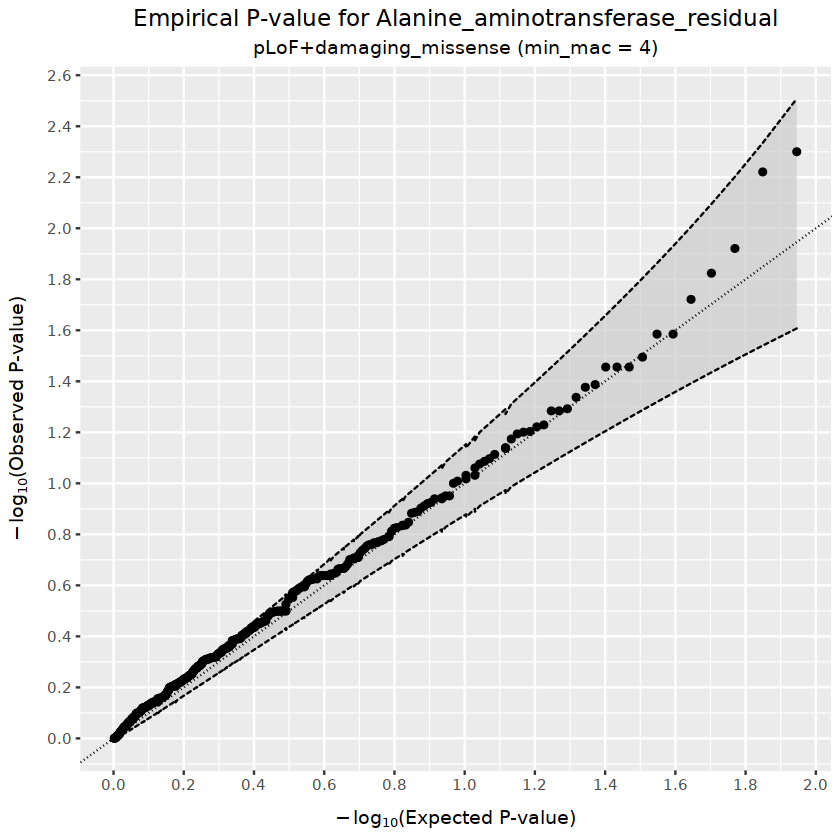

In [758]:
ggplot(dplt[dplt$pvalue.observed != Inf,], aes(x=pvalue.expected, y=pvalue.observed, ymax=clower, ymin=cupper)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    ggtitle("Empirical P-value for Alanine_aminotransferase_residual", "pLoF+damaging_missense (min_mac = 4)") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
source("scripts/post_hoc/utils.R")

In [68]:
# hash dosage as a string. This function simply concatenates all the dosgae counts
# into a long string, and subsequently applies a hash to this string.
hash_dosage <- function(DS_matrix, algo = "xxhash32"){
    require(digest)
    dosage_string <- unlist(apply(DS_matrix, 1, function(x) as.character(paste(x, collapse = '-'))))
    the_hash <- unlist(lapply(dosage_string, function(x) digest(x, algo=algo)))
    return(the_hash)
}

# get probability of knockout given number of heterozygotes
naive_knockout_p <- function(hets){
    if (hets > 1){
        return(1 - (2*((1/2)^hets)))
    } else {
        return(0)
    }
}

# fast way to calculate probability of being KO
calc_knockout_p_fast <- function(d){

     # hom ref are always zero
    d$P <- 0
    # hom alt are always one
    d$P[d$hom_alt_n > 1] <- 1
    # depends on count for phased hets
    index <- which((d$het_n > 1) & (d$hom_alt_n == 0))
    for (idx in index){
        hets <- d$het_n[idx]
        d$P[idx] <- naive_knockout_p(hets)
    }

    return(d$P)

}

# simple method to shuffle knockouts
shuffle_knockouts <- function(d){


    # NOTE: we now use "het" instead of "phased_het"
    # header of d
    # gene_id   s   unphased_het    phased_het  hom_alt_n   het pTKO
    # <chr> <int>   <int>   <int>   <int>   <int>   <dbl>
    # ENSG00000027644   1000028 0   0   0   0   0
    # ENSG00000027644   1000034 0   0   0   0   0
    # ENSG00000027644   1000087 0   0   0   0   0
    stopifnot('het_n' %in% colnames(d))
    stopifnot('hom_alt_n' %in% colnames(d))

    n <- nrow(d)
    p <- calc_knockout_p_fast(d)
    B <- rbinom(n = n, size = 1, prob = p)

    return(B)
}

# make header of VCF file
make_vcf_dosage_header <- function(chrom){
    vcf_format <- '##fileformat=VCFv4.2'
    vcf_entry <-  '##FORMAT=<ID=DS,Number=1,Type=Float,Description="">'
    vcf_filter <- '##FILTER=<ID=PASS,Description="All filters passed">"'
    vcf_i1 <- '##INFO=<ID=AC,Number=A,Type=Integer,Description="Knockout count multiplied by two">'
    vcf_i2 <- '##INFO=<ID=HASH,Number=A,Type=String,Description="Hash function applied to dosages">'
    vcf_contig <- paste0('##contig=<ID=',chrom,',length=81195210>')
    vcf_out <- paste(vcf_format, vcf_entry, vcf_filter, vcf_i1, vcf_i2, vcf_contig, sep = '\n')
    return(vcf_out)
}

# aggregate information from dosage matrix to create INFO rows
calc_info <- function(DS_matrix){
    stopifnot(ncol(DS_matrix) > 0)
    stopifnot(nrow(DS_matrix) > 0)
    # create INFO row by comining strings column wise
    d_info <- data.table(
        allele_count = rowSums(DS_matrix, na.rm = TRUE),
        hashes = hash_dosage(DS_matrix)
    )
    # append identifiers as specified in header
    d_info$allele_count <- paste0("AC=",d_info$allele_count,";")
    d_info$hashes <- paste0("HASH=",d_info$hashes)
    info_rows <- apply(d_info, 1, paste, collapse = "")
    return(info_rows)
}


# make a random string of n characters and numbers
random_string <- function(n){
    return(paste0(sample(c(letters, LETTERS), n, replace = TRUE), collapse = ""))
}

# make vcf-like rows for dosage entries
make_vcf_dosage_rows <- function(chrom, positions, marker, use_random_alleles = TRUE){
    rows <- length(positions)
    refs <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A0"))
    alts <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A1"))
    return(data.table(
      "#CHROM" = chrom,
      POS = positions,
      ID = marker,
      REF = refs,
      ALT = alts,
      QUAL = '.',
      FILTER = '.',
      INFO = '.',
      FORMAT = 'DS'
    ))
}

# read real variant data in long format (exported from hail)
# note: need position_last argument, since make_tabix will otherwise complain
# that the positions are not sorted.
format_real_variant_long_to_wide <- function(dt, position_last = 20000){

    stopifnot("s" %in% colnames(dt))
    stopifnot("locus" %in% colnames(dt))
    stopifnot("rsid" %in% colnames(dt))
    stopifnot("alleles" %in% colnames(dt))

    mapping <- dt[,c("locus","alleles","rsid")]
    mapping <- mapping[!duplicated(mapping),]

    # create mapping rows that are to be combined with actual dosages
    alleles <- as.data.frame(do.call(rbind, strsplit(gsub('(")|(\\])|(\\[)','',mapping$alleles), split = ',')))
    colnames(alleles) <- c("REF","ALT")
    mapping <- cbind(mapping, alleles)
    mapping$positions_recoded <- (position_last+1):(position_last+nrow(mapping))
    mapping$positions <- gsub("chr[0-9]+\\:", "",mapping$locus)
    mapping$marker <- paste0(mapping$locus, ":", mapping$REF, ":", mapping$ALT)
    mapping$chroms <- stringr::str_extract(mapping$locus, "chr[0-9]+")
    stopifnot(length(unique(mapping$positions)) == length(mapping$positions)) # can't handle SNPs at same pos
    mapping_rows <- data.table(
        "#CHROM" = mapping$chroms,
          POS = mapping$positions,
          ID = mapping$rsid,
          REF = mapping$REF,
          ALT = mapping$ALT,
          QUAL = '.',
          FILTER = '.',
          INFO = '.',
          FORMAT = 'DS',
          locus = mapping$locus
    )

    # go from long to wide format
    dt <- dt[,c('locus','s','DS')]
    dt <- data.table::dcast(locus~s, data = dt, value.var = "DS")

    # match mapping rows with dt rows
    #new_index <- match(dt$locus, mapping$locus)
    new_index <- match(mapping$locus, dt$locus)
    mapping_rows$locus <- NULL
    #mapping_rows <- mapping_rows[new_index,]
    dt <- dt[new_index,]

    #return(cbind(mapping_rows, dt))
    return(list(rows = mapping_rows, dosages = dt))

}

In [89]:
args <- list(
    seed = 1,
    permutations = 10,
    #input_path = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/permute/genes/chr1/ukb_eur_wes_200k_pLoF_damaging_missense_chr1_ENSG00000042781.tsv.gz",
    input_path = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/permute/genes/chr21/ukb_eur_wes_200k_pLoF_damaging_missense_chr21_ENSG00000141959.tsv.gz",
    marker = "ENSG00000141959" #"ENSG00000042781"
)

In [90]:

# seed for reproducibility
seed <- as.numeric(args$seed)
set.seed(seed)

# replicate knockout
n <- as.numeric(args$permutations)
d <- fread(args$input_path)
stopifnot(nrow(d) > 0)
#reps <- replicate(n, shuffle_knockouts(d))



In [134]:
# get sets of cis/chet kos
kos <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense", chrom = 1:22)
kos$is_cis <- kos$knockout == "Compound heterozygote (cis)"
kos$is_chet <- kos$knockout == "Compound heterozygote"


In [146]:
head(kos)

s,gene_id,transcript_id,varid,gts,AC,AF,AN,hom_alt_n,phased.a1,⋯,pKO,knockout,consequence_category,most_severe_consequence,revel_score,cadd_phred,exon,intron,is_cis,is_chet
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>
4493380,ENSG00000001461,ENST00000374399,chr1:24464071:GAAGAA:G;chr1:24464078:CCCAT:C,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,0,Compound heterozygote (cis),pLoF;pLoF,frameshift_variant;frameshift_variant,,,11/12;11/12,,TRUE,FALSE
4659370,ENSG00000001461,ENST00000374399,chr1:24464071:GAAGAA:G;chr1:24464078:CCCAT:C,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,0,Compound heterozygote (cis),pLoF;pLoF,frameshift_variant;frameshift_variant,,,11/12;11/12,,TRUE,FALSE
3010034,ENSG00000004455,ENST00000354858,chr1:33013390:G:T;chr1:33013393:C:T,1|0;1|0,2;3,5.6629e-06;8.4944e-06,353174;353174,0,2,⋯,0,Compound heterozygote (cis),damaging_missense;damaging_missense,missense_variant;missense_variant,0.752;0.854,26.6;28.2,6/6;6/6,,TRUE,FALSE
5643583,ENSG00000004455,ENST00000354858,chr1:33013390:G:T;chr1:33013393:C:T,0|1;0|1,2;3,5.6629e-06;8.4944e-06,353174;353174,0,0,⋯,0,Compound heterozygote (cis),damaging_missense;damaging_missense,missense_variant;missense_variant,0.752;0.854,26.6;28.2,6/6;6/6,,TRUE,FALSE
4650058,ENSG00000006555,ENST00000371276,chr1:54800699:GT:G;chr1:54800702:GCCCTGCTCGGC:G,0|1;0|1,2;2,5.6629e-06;5.6629e-06,353174;353174,0,0,⋯,0,Compound heterozygote (cis),pLoF;pLoF,frameshift_variant;frameshift_variant,,,1/7;1/7,,TRUE,FALSE
5724094,ENSG00000006555,ENST00000371276,chr1:54800699:GT:G;chr1:54800702:GCCCTGCTCGGC:G,1|0;1|0,2;2,5.6629e-06;5.6629e-06,353174;353174,0,2,⋯,0,Compound heterozygote (cis),pLoF;pLoF,frameshift_variant;frameshift_variant,,,1/7;1/7,,TRUE,FALSE


In [ ]:
kos <- read_ukb_wes_kos(annotation = "pLoF_damaging_missense", chrom = 1:22)
kos$is_cis <- kos$knockout == "Compound heterozygote (cis)"
kos$is_chet <- kos$knockout == "Compound heterozygote"
genes_to_run <- Reduce(merge,
   list(
       aggregate(is_cis ~ gene_id, data = kos, FUN=sum),
       aggregate(is_chet ~ gene_id, data = kos, FUN=sum)
       )
   )
colnames(genes_to_run)[1] <- "MarkerID"

In [ ]:


# subset by chets/cis counts
min_cis <- 4 #as.numeric(args$min_cis)
min_chet <- 4 #as.numeric(args$min_chet)
markers_keep <- genes_to_run$MarkerID[(genes_to_run$is_cis >= min_cis) & (genes_to_run$is_chet >= min_chet)]
genes_to_run <- genes_to_run[genes_to_run$MarkerID %in% markers_keep, ]
genes_to_run$CHR <- paste0("chr",ensembl_to_contig[genes_to_run$MarkerID])
genes_to_run$hgnc_symbol <- ensembl_to_hgnc[genes_to_run$MarkerID]

In [135]:
combined <- Reduce(merge, 
       list(
           aggregate(is_cis ~ gene_id, data = kos, FUN=sum), 
           aggregate(is_chet ~ gene_id, data = kos, FUN=sum)
           )
       )

In [147]:
nrow(combined)
combined[(combined$is_cis >= 4) & (combined$is_chet >= 4),]

[1] 4781

In [93]:
shuffle_knockouts2 <- function(d, kos){
    
    # get ids from the various grous
    eid_cis <- kos$s[kos$knockout == "Compound heterozygote (cis)"]
    eid_chet <- kos$s[kos$knockout == "Compound heterozygote"]
    eid_both <- c(eid_cis, eid_chet)
    eid_homs <- kos$s[kos$knockout == "Homozygote"]
    
    # to preserve the allele count we randomly assign chets between cis & chets
    n_samples <- length(d$s)
    v <- rep(0, n_samples)

    # assign homs as these never change
    v[which(d$s %in% eid_homs)] <- 1

    # randomly assign chets to two-hit variants
    n_chets <- length(eid_chet)
    eid_sampled <- sample(eid_both, size = n_chets, replace = FALSE)
    eid_not_sampled <- eid_both[!eid_both %in% eid_sampled]

    # assing these to be our new knockouts
    v[which(d$s %in% eid_sampled)] <- 1

    # these are our new cis
    v[which(d$s %in% eid_not_sampled)] <- 0
    return(v)
}

create_original_ko <- function(d, kos){
    
     # get ids from the various grous
    eid_chet <- kos$s[kos$knockout == "Compound heterozygote"]
    eid_homs <- kos$s[kos$knockout == "Homozygote"]
    
    # to preserve the allele count we randomly assign chets between cis & chets
    n_samples <- length(d$s)
    v <- rep(0, n_samples)

    # assign homs as these never change
    v[which(d$s %in% eid_homs)] <- 1
    v[which(d$s %in% eid_chet)] <- 1
    return(v)
}

In [94]:
# replicate knockout
n <- as.numeric(args$permutations)
d <- fread(args$input_path)
stopifnot(nrow(d) > 0)
reps <- replicate(n, shuffle_knockouts2(d, kos))
rownames(reps) <- d$s
reps <- data.table(t(reps))

# convert to dosage
dosage <- reps * 2


# load real conditioning variants, i.e. the actual
# dosages/genotypes of the variants that we would like
# to condition on
if (args$enable_cond_pipeline) {
  cond_dt <- fread(args$input_path_cond_genotypes)
  cond_dt$chr <- stringr::str_extract(cond_dt$locus, "chr[0-9]+")
  cond_dt <- cond_dt[cond_dt$chr %in% args$chrom]
  n_real_markers <- length(unique(cond_dt$locus))
} else {
  n_real_markers <- 0
}

# if there are conditiONIng markers available include them downstream.
if (n_real_markers > 0){

    # how many markers were found?
    write(paste("Note:",n_real_markers, "real marker(s) found. These will be included as unshuffled in permuted VCF."),stdout())

    # ensure that samples are overlapping
    sample_overlap <- unique(intersect(cond_dt$s, d$s))

    # subset dosage matrix (with permuted phased)
    rows <- make_vcf_dosage_rows(args$chrom, 1:n, args$vcf_id)
    dosage <- dosage[,colnames(dosage) %in% sample_overlap, with = FALSE]

    # subset real dosage matrix (with actual calls/DS)
    cond_dt <- cond_dt[cond_dt$s %in% sample_overlap,]
    cond_lst <- format_real_variant_long_to_wide(cond_dt, n)

    # get long format
    cond_rows <- cond_lst$rows
    cond_dosage <- cond_lst$dosage

    # match columns
    cond_dosage$locus <- NULL
    cond_dosage <- cond_dosage[,colnames(dosage), with = FALSE]

    # combine columns and rows. Note: that rbind order
    # matters here when using tabix!
    stopifnot(ncol(rows) == ncol(cond_rows))
    combined_dosages <- rbind(dosage, cond_dosage)
    combined_meta <- rbind(rows, cond_rows)
    final <- cbind(combined_meta, combined_dosages)

    # calculate some info stats
    sds <- unlist(apply(combined_dosages, 1, function(x) sd(x, na.rm = TRUE)))

    # calculate INFO column
    final$INFO <- calc_info(combined_dosages)

    # how many real markers have missing dosages
    n_real_count <- nrow(cond_dosage)
    n_real_miss <- sum(is.na(apply(cond_dosage, 1, sd)))
    write(paste0("Note: ", n_real_miss, " of ", n_real_count, " real markers have one or more missing dosages."), stdout())

    # debugging - are SNPs monoprhic and thus
    # the resulting matrix not invertible?
    #cond_dosage_sd <- apply(cond_dosage, 1, sd)
    #cond_dosage_af <- apply(cond_dosage, 1, mean)
    #cond_rows$sd <- cond_dosage_sd
    #cond_rows$af <- cond_dosage_af

}  else {

    rows <- make_vcf_dosage_rows(args$chrom, 1:n, args$vcf_id)
    rows_dosage <- cbind(rows, dosage)
    final <- rows_dosage
    final$INFO <- calc_info(dosage)
    sds <- unlist(apply(dosage, 1, sd))
}

ERROR: Error in if (args$enable_cond_pipeline) {: argument is of length zero


In [95]:
orig <- create_original_ko(d, kos)
orig_dosage <- t(orig * 2)
orig_rows <- make_vcf_dosage_rows(args$chrom, n+1, "actual")
orig_rows_dosage <- cbind(orig_rows, orig_dosage)
orig_rows_dosage$INFO <- calc_info(orig_dosage)
colnames(orig_rows_dosage) <- colnames(final)

In [96]:
rows <- make_vcf_dosage_rows(args$chrom, 1:n, "ENSG1111")
rows_dosage <- cbind(rows, dosage)
final <- rows_dosage
final$INFO <- calc_info(dosage)
sds <- unlist(apply(dosage, 1, sd))

In [97]:
rbind(final, orig_rows_dosage)[,1:20]

POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,1000028,1000034,1000087,1000118,1000120,1000162,1000171,1000196,1000254,1000278,1000297,1000302
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG1111,LUtB,yVyw,.,.,AC=12;HASH=447641d1,DS,0,0,0,0,0,0,0,0,0,0,0,0
2,ENSG1111,tRwf,TtMC,.,.,AC=12;HASH=0e431443,DS,0,0,0,0,0,0,0,0,0,0,0,0
3,ENSG1111,NRyf,mvCB,.,.,AC=12;HASH=513461ad,DS,0,0,0,0,0,0,0,0,0,0,0,0
4,ENSG1111,MYPf,RVGS,.,.,AC=12;HASH=ed8faf35,DS,0,0,0,0,0,0,0,0,0,0,0,0
5,ENSG1111,xFnb,uELq,.,.,AC=12;HASH=66426003,DS,0,0,0,0,0,0,0,0,0,0,0,0
6,ENSG1111,Srvn,iMws,.,.,AC=12;HASH=97f84175,DS,0,0,0,0,0,0,0,0,0,0,0,0
7,ENSG1111,LaYY,XzVQ,.,.,AC=12;HASH=50c8dd3d,DS,0,0,0,0,0,0,0,0,0,0,0,0
8,ENSG1111,NfwR,DPFM,.,.,AC=12;HASH=d9e7c4c8,DS,0,0,0,0,0,0,0,0,0,0,0,0
9,ENSG1111,fNMk,YCHj,.,.,AC=12;HASH=4ae8dae8,DS,0,0,0,0,0,0,0,0,0,0,0,0


In [78]:
final[,1:20]

POS,REF,ALT,QUAL,FILTER,INFO,FORMAT,1000028,1000034,1000087,1000118,1000120,1000162,1000171,1000196,1000254,1000278,1000297,1000302,1000329
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,XzVQ,DPFM,.,.,AC=16;HASH=1b995cfb,DS,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
reps <- replicate(10, shuffle_knockouts2(d, kos))

In [ ]:
d <- fread()

In [56]:
#d <- fread("data/permute/permutations/chr21/ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_spiro_visual_impairment_and_blindness.pvalues.txt.gz")

In [98]:
fpath <- "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/permute/permutations/chr21/ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_1.vcf.gz"

In [109]:
cmd <- paste0("zcat ", fpath, '| grep -E "(CHROM)|(ENSG00000141959)|(actual)" | tail -n 2')

In [110]:
d <- fread(cmd <- cmd)

Taking input= as a system command ('zcat /well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/permute/permutations/chr21/ENSG00000141959/ukb_eur_wes_200k_pLoF_damaging_missense_permuted_chr21_ENSG00000141959_1.vcf.gz| grep -E "(CHROM)|(ENSG00000141959)|(actual)" | tail -n 2') and a variable has been used in the expression passed to `input=`. Please use fread(cmd=...). There is a security concern if you are creating an app, and the app could have a malicious user, and the app is not running in a secure environment; e.g. the app is running as root. Please read item 5 in the NEWS file for v1.11.6 for more information and for the option to suppress this message.



In [111]:
d[,1:10]

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
chr21,100,ENSG00000141959,emrP,JnWd,.,.,AC=6;HASH=c4993f38,DS,0
chr21,101,actual,MsdR,aecG,.,.,AC=12;HASH=d355b5fa,DS,0


In [116]:
any(d[1,10:ncol(d)] == 2)

[1] TRUE

In [114]:
sum(d[2,10:ncol(d)])

[1] 12

In [5]:
# simple method to shuffle knockouts
shuffle_knockouts <- function(d){


    # NOTE: we now use "het" instead of "phased_het"
    # header of d
    # gene_id   s   unphased_het    phased_het  hom_alt_n   het pTKO
    # <chr> <int>   <int>   <int>   <int>   <int>   <dbl>
    # ENSG00000027644   1000028 0   0   0   0   0
    # ENSG00000027644   1000034 0   0   0   0   0
    # ENSG00000027644   1000087 0   0   0   0   0
    stopifnot('het_n' %in% colnames(d))
    stopifnot('hom_alt_n' %in% colnames(d))

    n <- nrow(d)
    p <- calc_knockout_p_fast(d)
    B <- rbinom(n = n, size = 1, prob = p)

    return(B)
}

0
0
0
0
0
0
0
0
0
0
0


## Omos 

In [66]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)

In [128]:
# load reference intervals
d <- fread("/well/lindgren/flassen/projects/omos/extdata/230129_sample_tests_from_biobank_for_prototype.txt")
colnames(d)[2] <- "strat"

# annotate with sex and age 
d$sex <- as.factor(as.integer(grepl("female", d$strat)))
d$age_lower <- as.integer(gsub("age","",stringr::str_extract(d$strat, pattern = "age[0-9]+")))
d$age_upper <- as.integer(gsub("age[0-9]+_","",stringr::str_extract(d$strat, pattern = "age[0-9]+_[0-9]+")))
d$age_unit <- gsub("_","",stringr::str_extract(d$strat, pattern = "_([A-Z]|[a-z])$"))
biomarkers <- unique(d$biomarker)

# we subset to adult with defined age ranges
d <- d[(d$age_lower >= 19) | (is.na(d$age_lower)), ] # adults
d <- d[(is.na(d$age_unit)) | (d$age_unit == "y"),] # adults (in years)
stopifnot(d$biomarker %in% biomarkers)

In [163]:
# load biomarkers
cts <- fread("data/phenotypes/curated_covar_phenotypes_cts_500k.tsv")
cts <- cts[!is.na(cts$age),]
cts$sex <- factor(cts$sex)
stopifnot(all(d$biomarker %in% colnames(cts)))


In [164]:
# simple estimate for age cutoff
b <- d$biomarker[16]
d_subset <- d[d$biomarker == b,]
age_range <- median(sort(unique(d_subset$age_lower, d_subset$age_upper)))
cts$age_cutoff <- cts$age >= age_range

In [165]:
d_subset

biomarker,strat,min,max,unit,sex,age_lower,age_upper,age_unit
<chr>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<int>,<int>,<chr>
Urea,"female, age20_50_y",2.5,6.7,mmol/L,1,20,50,y
Urea,"female, age50_inf_y",3.5,7.2,mmol/L,1,50,NA,y
Urea,"male, age20_50_y",3.2,7.4,mmol/L,0,20,50,y
Urea,"male, age50_inf_y",3.0,9.2,mmol/L,0,50,NA,y


Warning message:
"Removed 69719 rows containing non-finite values (`stat_density()`)."
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
"Removed 69719 rows containing non-finite values (`stat_bin()`)."


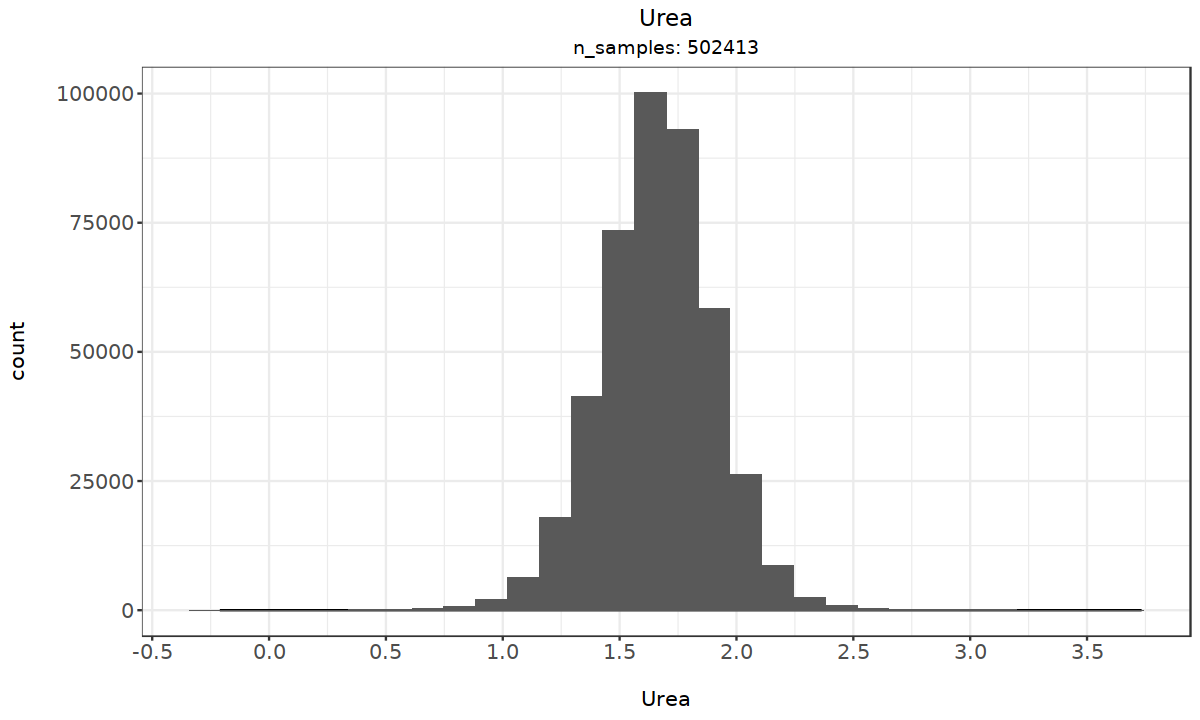

In [172]:
ggplot(cts, aes_string(x = b)) +
    #annotate("rect", xmin=ref[1], xmax=ref[2], ymin=0, ymax=Inf, alpha=0.2, fill="grey30") +
    geom_density(alpha = 0.5) +
    geom_histogram(position="dodge") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme_bw() +
    ggtitle(b, paste("n_samples:", length(!is.na(cts[[b]])))) +
    theme(
            axis.text=element_text(size=12),
            axis.title=element_text(size=12),
            axis.title.x = element_text(margin=ggplot2::margin(t=16)),
            axis.title.y = element_text(margin=ggplot2::margin(r=16)),
            plot.title = element_text(hjust=0.5),
            plot.subtitle = element_text(hjust=0.5),
            legend.text=element_text(size=15))

Warning message:
"Removed 69719 rows containing non-finite values (`stat_density()`)."
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
"Removed 69719 rows containing non-finite values (`stat_bin()`)."


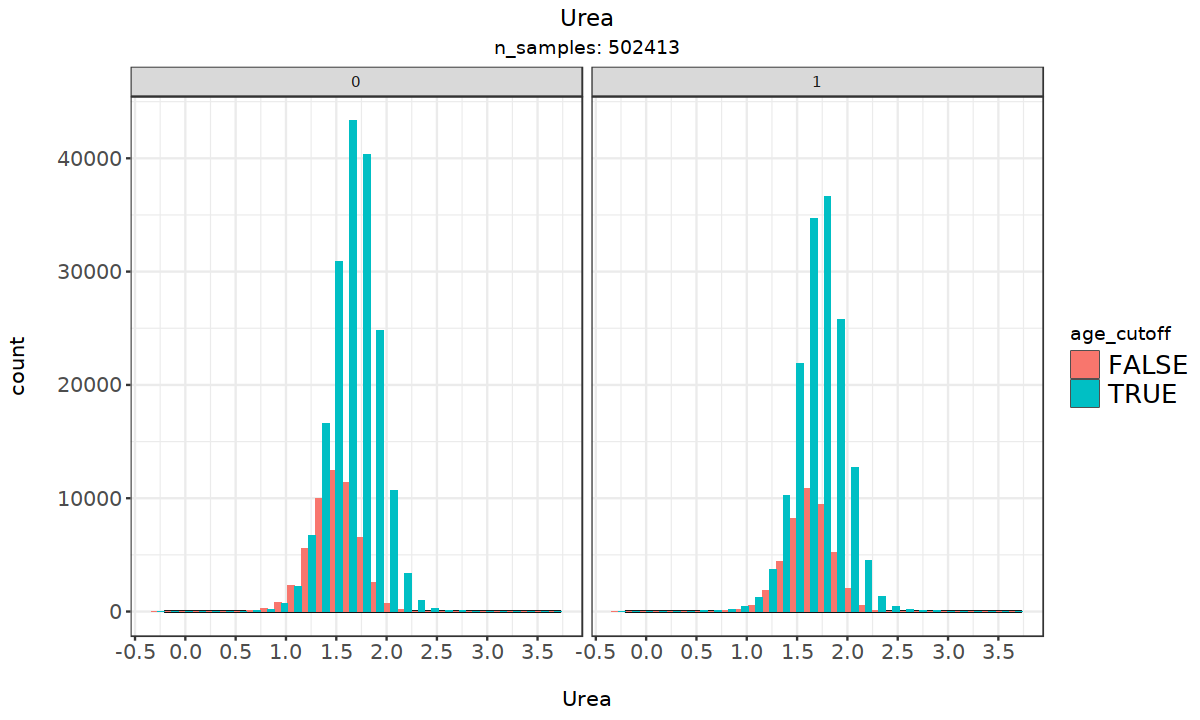

In [171]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(cts, aes_string(x = b, fill="age_cutoff")) +
    #annotate("rect", xmin=ref[1], xmax=ref[2], ymin=0, ymax=Inf, alpha=0.2, fill="grey30") +
    geom_density(alpha = 0.5) +
    geom_histogram(position="dodge") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme_bw() +
    ggtitle(b, paste("n_samples:", length(!is.na(cts[[b]])))) +
    theme(
            axis.text=element_text(size=12),
            axis.title=element_text(size=12),
            axis.title.x = element_text(margin=ggplot2::margin(t=16)),
            axis.title.y = element_text(margin=ggplot2::margin(r=16)),
            plot.title = element_text(hjust=0.5),
            plot.subtitle = element_text(hjust=0.5),
            legend.text=element_text(size=15)) +
    facet_wrap(~sex)
    